### Homework 2: Data Analysis for Recruitment Data
Owen Randolph, 10/26/2024, DSCI-590: Applied Data Science

Data Description: The dataset was originally published by IBM sometime before 2017, providing fictional data from an HR department of a medical biotechnology company and was created by IBM data scientists.  It can also be found on Kaggle: https://www.kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset along with a guide to the categorical data.

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.tree import DecisionTreeClassifier
from sklearn import metrics
from factor_analyzer import FactorAnalyzer
from factor_analyzer.factor_analyzer import calculate_bartlett_sphericity

### Load and Prepare Data

In [57]:
# Read in the recruitment data
data = pd.read_csv("recruitment_evaluation_data.csv")

In [58]:
data.head()

,Unnamed: 0,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeNumber,...,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,SalesRating,HireSource,Campus
0,1,41,1,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,...,8,0,1,6,4,0,5,1.08819,Applied Online,NaN
1,2,49,0,Travel_Frequently,279,Research & Development,8,1,Life Sciences,2,...,10,3,3,10,7,1,7,NaN,NaN,NaN
2,3,37,1,Travel_Rarely,1373,Research & Development,2,2,Other,4,...,7,3,3,0,0,0,0,NaN,Campus,Tech
3,4,33,0,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,5,...,8,3,3,8,7,3,0,NaN,NaN,NaN
4,5,27,0,Travel_Rarely,591,Research & Development,2,1,Medical,7,...,6,3,3,2,2,2,2,NaN,Referral,NaN


In [59]:
# Check the number of rows and columns of the dataset
data.shape

(1470, 36)

In [60]:
# Check the data types in columns
data.dtypes

Unnamed: 0                    int64
Age                           int64
Attrition                     int64
BusinessTravel               object
DailyRate                     int64
Department                   object
DistanceFromHome              int64
Education                     int64
EducationField               object
EmployeeNumber                int64
EnvironmentSatisfaction       int64
Gender                       object
HourlyRate                    int64
JobInvolvement                int64
JobLevel                      int64
JobRole                      object
JobSatisfaction               int64
MonthlyIncome                 int64
MonthlyRate                   int64
NumCompaniesWorked            int64
OverTime                     object
PercentSalaryHike             int64
PerformanceRating             int64
RelationshipSatisfaction      int64
StandardHours                 int64
StockOptionLevel              int64
TotalWorkingYears             int64
TrainingTimesLastYear       

In [61]:
# Display summary statistics
data.describe()

,Unnamed: 0,Age,Attrition,DailyRate,DistanceFromHome,Education,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,...,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,SalesRating
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,446.000000
mean,735.500000,36.923810,0.161224,802.485714,9.192517,2.912925,1024.865306,2.721769,65.891156,2.729932,...,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129,1.082607
std,424.496761,9.135373,0.367863,403.509100,8.106864,1.024165,602.024335,1.093082,20.329428,0.711561,...,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136,0.710042
min,1.000000,18.000000,0.000000,102.000000,1.000000,1.000000,1.000000,1.000000,30.000000,1.000000,...,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,-0.710827
25%,368.250000,30.000000,0.000000,465.000000,2.000000,2.000000,491.250000,2.000000,48.000000,2.000000,...,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000,0.584444
50%,735.500000,36.000000,0.000000,802.000000,7.000000,3.000000,1020.500000,3.000000,66.000000,3.000000,...,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000,1.070143
75%,1102.750000,43.000000,0.000000,1157.000000,14.000000,4.000000,1555.750000,4.000000,83.750000,3.000000,...,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000,1.532488
max,1470.000000,60.000000,1.000000,1499.000000,29.000000,5.000000,2068.000000,4.000000,100.000000,4.000000,...,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000,3.666740


For the sake of clarity, and since it does not mention metrics in the ReadMe file, I will assume for the purposes of this assignment that:
DailyRate & Hourly Rate: USD, DistanceFromHome: miles.  The Education feature is not clear enough and will be dropped, along with "Unnamed: 0".

In [62]:
# Prep column names for dropping columns
data.columns = data.columns.str.strip()

In [63]:
# "Unnamed: 0", hours and income features except monthly income columns will be dropped
data = data.drop(columns=['Unnamed: 0', 'StandardHours', 'HourlyRate', 'MonthlyRate', 'DailyRate'], errors='ignore')

In [64]:
data.head()

,Age,Attrition,BusinessTravel,Department,DistanceFromHome,Education,EducationField,EmployeeNumber,EnvironmentSatisfaction,Gender,...,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,SalesRating,HireSource,Campus
0,41,1,Travel_Rarely,Sales,1,2,Life Sciences,1,2,Female,...,8,0,1,6,4,0,5,1.08819,Applied Online,NaN
1,49,0,Travel_Frequently,Research & Development,8,1,Life Sciences,2,3,Male,...,10,3,3,10,7,1,7,NaN,NaN,NaN
2,37,1,Travel_Rarely,Research & Development,2,2,Other,4,4,Male,...,7,3,3,0,0,0,0,NaN,Campus,Tech
3,33,0,Travel_Frequently,Research & Development,3,4,Life Sciences,5,4,Female,...,8,3,3,8,7,3,0,NaN,NaN,NaN
4,27,0,Travel_Rarely,Research & Development,2,1,Medical,7,1,Male,...,6,3,3,2,2,2,2,NaN,Referral,NaN


In [65]:
# Check for missing values
data.isnull().sum()

Age                            0
Attrition                      0
BusinessTravel                 0
Department                     0
DistanceFromHome               0
Education                      0
EducationField                 0
EmployeeNumber                 0
EnvironmentSatisfaction        0
Gender                         0
JobInvolvement                 0
JobLevel                       0
JobRole                        0
JobSatisfaction                0
MonthlyIncome                  0
NumCompaniesWorked             0
OverTime                       0
PercentSalaryHike              0
PerformanceRating              0
RelationshipSatisfaction       0
StockOptionLevel               0
TotalWorkingYears              0
TrainingTimesLastYear          0
WorkLifeBalance                0
YearsAtCompany                 0
YearsInCurrentRole             0
YearsSinceLastPromotion        0
YearsWithCurrManager           0
SalesRating                 1024
HireSource                   618
Campus    

Upon inspection, we see that Sales Ratings are only for salespeople, so this is systematic missingness. The Campus column only indicates certain types of schools, with missing data for employees with unspecified campuses or possibly no college.  Hire Source contains significant missing data, likely Missing Completely at Random, as the missingness does not look to be related to the data itself. For the purpose of this analysis, we will drop these categories.

In [66]:
data = data.drop(columns=['SalesRating', 'HireSource', 'Campus'])

### Exploratory Data Analysis

We will create some basic plots to visualize the data, specifically related to Attrition, and look for correlation patterns.

In [67]:
attrition_counts = data['Attrition'].value_counts()
attrition_counts

Attrition
0    1233
1     237
Name: count, dtype: int64

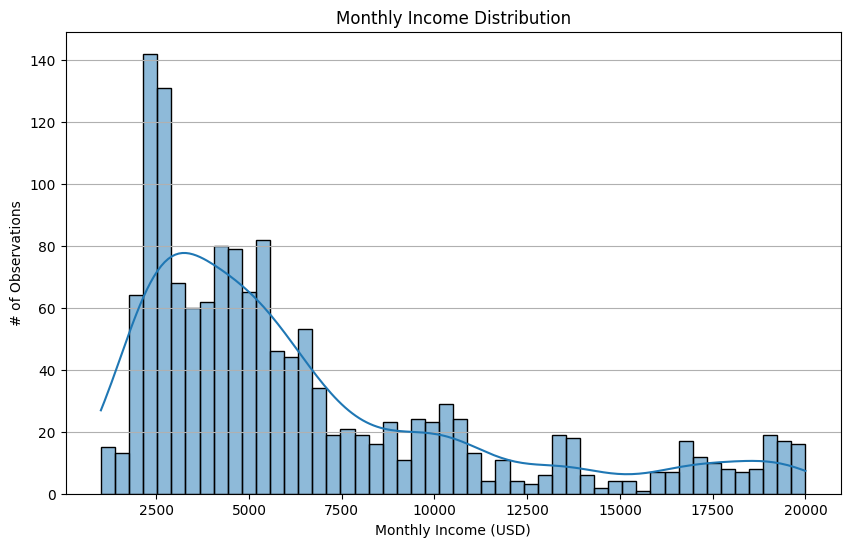

In [68]:
# Histogram for Monthly Income Distribution 
plt.figure(figsize=(10, 6))
sns.histplot(data=data, x='MonthlyIncome', bins = 50, kde=True)
plt.title("Monthly Income Distribution")
plt.xlabel("Monthly Income (USD)")
plt.ylabel("# of Observations")
plt.grid(axis='y')

plt.show()

C:\Users\orand\AppData\Local\Temp\ipykernel_405716\3920570647.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Attrition', y='MonthlyIncome', data=data, palette='coolwarm', order=[0,1])


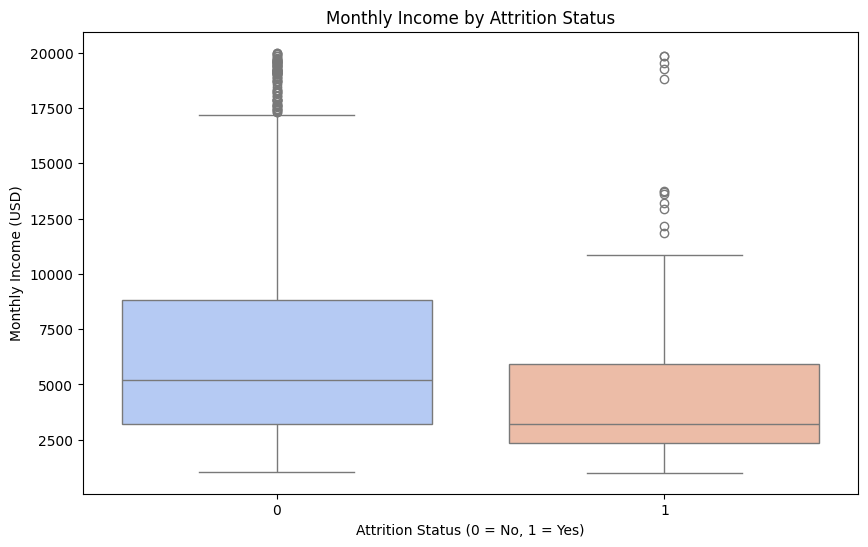

In [69]:
# Box plots for Monthly Income based on Attrition
plt.figure(figsize=(10, 6))
sns.boxplot(x='Attrition', y='MonthlyIncome', data=data, palette='coolwarm', order=[0,1])

# Add titles and labels
plt.title("Monthly Income by Attrition Status")
plt.xlabel("Attrition Status (0 = No, 1 = Yes)")
plt.ylabel("Monthly Income (USD)")

# Show the plot
plt.show()

People who left the company had lower average monthly income that those who have not left the company.  There are outliers in the upper extreme of the attrition dataset, and there are many outliers among the highest salaries in the no attrition cases.  However, these so not need to be removed from the data for further analysis, as they are not errors, but simply features.  These indicate right/positive skewed datasets. 

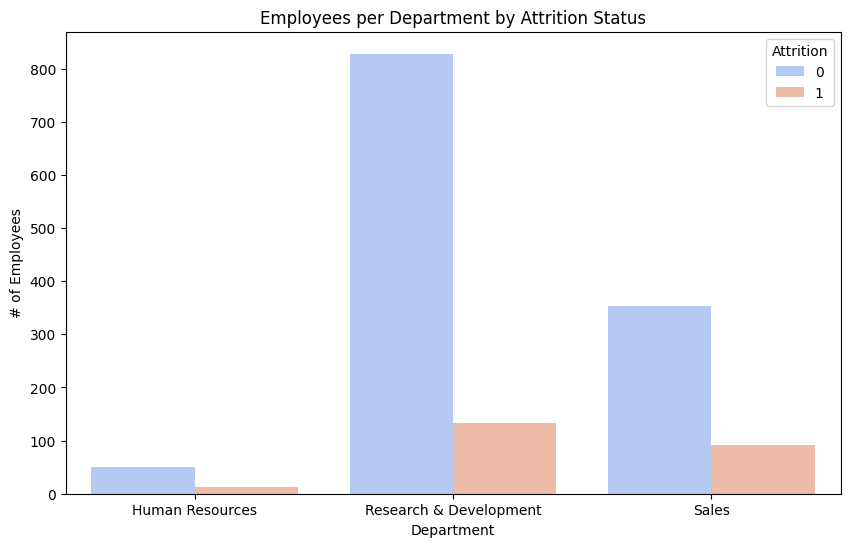

In [70]:
# Bar Chart of numbers of employees per department divided by attrition status
dept_attrition_counts = data.groupby(['Department', 'Attrition']).size().reset_index(name='Counts')

# Create the bar chart using Seaborn
plt.figure(figsize=(10, 6))
sns.barplot(x='Department', y='Counts', hue='Attrition', data=dept_attrition_counts, palette='coolwarm')

# Customize the plot
plt.title("Employees per Department by Attrition Status")
plt.xlabel("Department")
plt.ylabel("# of Employees")
plt.xticks(rotation=0)

plt.show()

In [71]:
for department in data['Department'].unique():
    # Filter data by department
    department_data = data[data['Department'] == department]
    
    # Count occurrences of Attrition values (1 and 0)
    attrition_counts = department_data['Attrition'].value_counts()

    # Count total Employees per dept
    total_employees = len(department_data)

    attrition_proportions = {
        'Attrition = 1': attrition_counts.get(1, 0) / total_employees,
        'Attrition = 0': attrition_counts.get(0, 0) / total_employees
    }
    
    print(f"Department: {department}")
    print(f"  Proportion of Attrition = 1: {attrition_proportions['Attrition = 1']:.2f}")
    print(f"  Proportion of Attrition = 0: {attrition_proportions['Attrition = 0']:.2f}")

Department: Sales
  Proportion of Attrition = 1: 0.21
  Proportion of Attrition = 0: 0.79
Department: Research & Development
  Proportion of Attrition = 1: 0.14
  Proportion of Attrition = 0: 0.86
Department: Human Resources
  Proportion of Attrition = 1: 0.19
  Proportion of Attrition = 0: 0.81


The department with the highest rate is sales, followed by HR, and then R&D.

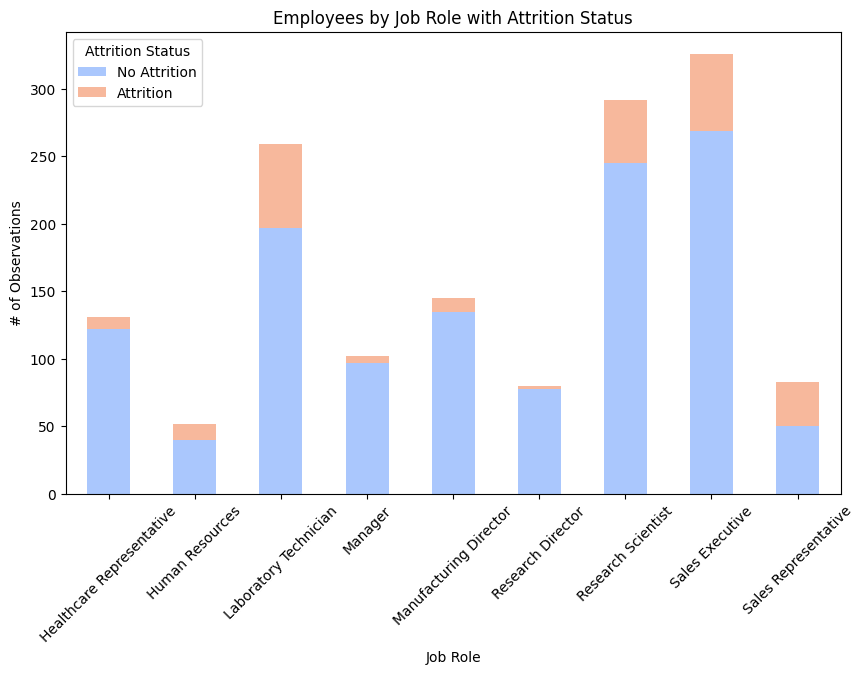

In [72]:
# Bar Chart of the distribution of jobs by title
job_role_attrition = data.groupby(['JobRole', 'Attrition']).size().unstack(fill_value=0)

# Use palette from previous charts:
coolwarm = sns.color_palette("coolwarm", n_colors=2)

# Create a stacked bar chart
fig, ax = plt.subplots(figsize=(10, 6))
job_role_attrition.plot(kind='bar', stacked=True, ax=ax, color=coolwarm)

# Set titles and labels
ax.set_title("Employees by Job Role with Attrition Status")
ax.set_xlabel("Job Role")
ax.set_ylabel("# of Observations")
plt.xticks(rotation=45)
ax.legend(['No Attrition', 'Attrition'], title='Attrition Status')

plt.show()

Laboratory Technicians have the highest total attrition, while sales reps have the highest proportion of attrition.  Reseach directors are the least likely to leave the company.

For now, we can look at the correlation of numeric data. 

In [73]:
numeric_data = data.select_dtypes(include=['float64', 'int64'])

# Calculate the correlation matrix for numeric columns only
correlation_matrix = numeric_data.corr()

<Axes: >

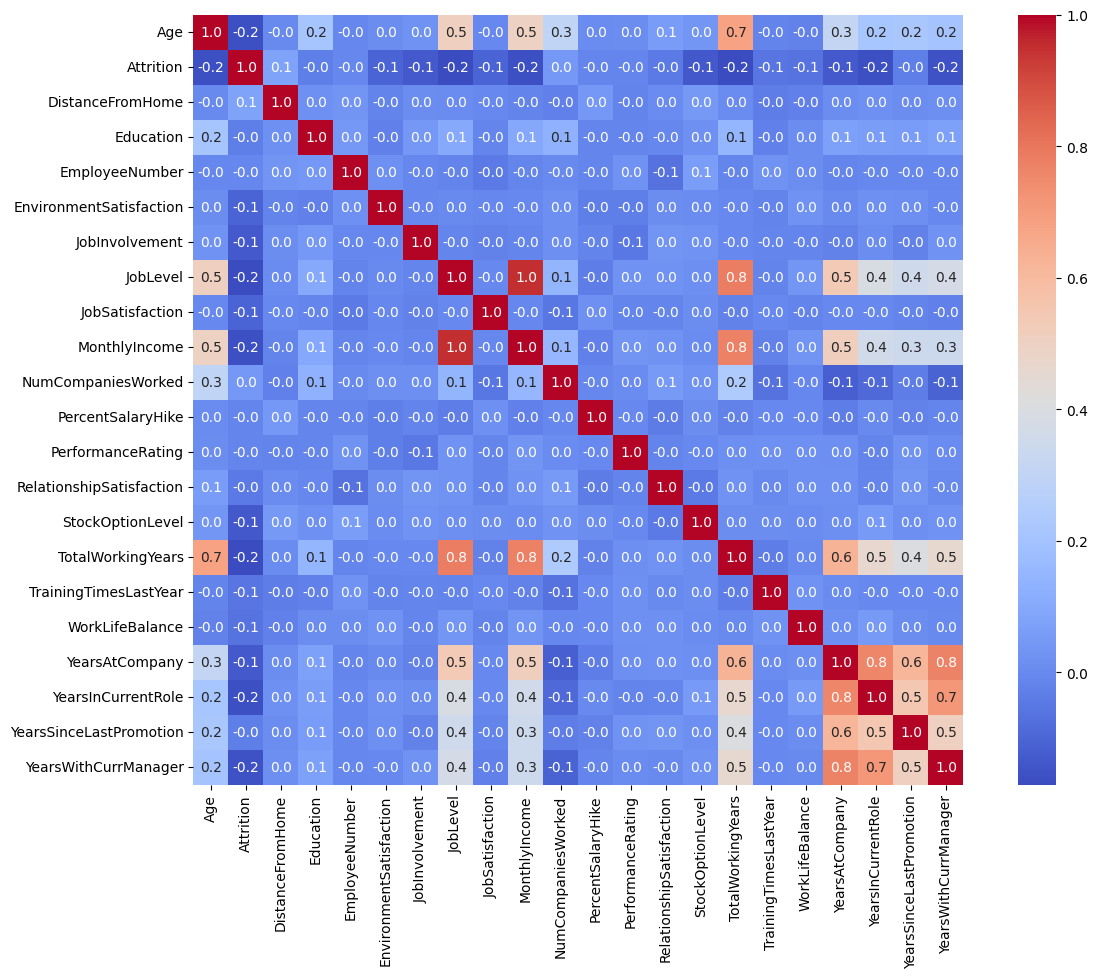

In [74]:
# Heatmap to easily identify correlations between numeric features
plt.figure(figsize=(14,10))
sns.heatmap(correlation_matrix, annot=True, fmt=".1f", cmap='coolwarm', square=True, cbar=True)

It is seen that job level is the most strongly correlated with monthly salary (0.95), with total years worked (0.77) and, to some degree, age (0.50). It appears that attrition, which we are also interested in, has weak correlation with many variables, and none are signficant.

Examining the normality of relevant variables and Testing for homosceasticity are not necessary for logistic regression because they are used for linear regression.  In terms of assessing and mitigating collinearity among variables, even though it is shown that no variable is correlated more than |-0.2| with Attrition, we will perform Variance Inflation Factor Test to quantify the multicollinearity of predictors.

In [75]:
features = data[['JobLevel', 'MonthlyIncome', 'TotalWorkingYears', 'Age']]
features_with_const = sm.add_constant(features)

vif_data = pd.DataFrame()
vif_data['Feature'] = features_with_const.columns
vif_data['VIF'] = [variance_inflation_factor(features_with_const.values, i) for i in range(features_with_const.shape[1])]

print(vif_data)

             Feature        VIF
0              const  23.660642
1           JobLevel  10.956666
2      MonthlyIncome  10.574985
3  TotalWorkingYears   3.639605
4                Age   1.868771


As VIF of over 10 is problematic, Job Level will be removed, as it is highly correlated with Monthly Income.  We will test this new dataset in training.

In [76]:
data = data.drop('JobLevel', axis = 1)

In [77]:
features = data[['MonthlyIncome', 'TotalWorkingYears', 'Age']]
features_with_const = sm.add_constant(features)

vif_data = pd.DataFrame()
vif_data['Feature'] = features_with_const.columns
vif_data['VIF'] = [variance_inflation_factor(features_with_const.values, i) for i in range(features_with_const.shape[1])]

print(vif_data)

             Feature        VIF
0              const  20.938343
1      MonthlyIncome   2.492674
2  TotalWorkingYears   3.490791
3                Age   1.868690


#### Pre-processing

##### Categorical Encoding
In order to be able to use non-numeric categorical data, it must be encoded:

In [78]:
# One Hot Encode Categorical data
data_encoded = pd.get_dummies(data, columns=['BusinessTravel', 'Gender', 'OverTime', 'EducationField', 'JobRole', 'Department'], drop_first=False)

# Since get_dummies already includes the new encoded columns, you don't need to concatenate
# Just assign the new DataFrame to your original variable
data = data_encoded

# Display the updated DataFrame
print(data.head())

   Age  Attrition  DistanceFromHome  Education  EmployeeNumber  \
0   41          1                 1          2               1   
1   49          0                 8          1               2   
2   37          1                 2          2               4   
3   33          0                 3          4               5   
4   27          0                 2          1               7   

   EnvironmentSatisfaction  JobInvolvement  JobSatisfaction  MonthlyIncome  \
0                        2               3                4           5993   
1                        3               2                2           5130   
2                        4               2                3           2090   
3                        4               3                3           2909   
4                        1               3                2           3468   

   NumCompaniesWorked  ...  JobRole_Laboratory Technician  JobRole_Manager  \
0                   8  ...                          Fals

### Logistic Regression Analysis

For predicting attrition, logistic regression will be used, as this target variable is binary.  Lasso regression and Ridge regression will also be tested.  Although no variables are correlated with attrition, the aim is to see if combinations of variables are more strongly correlated with likelihood of attrition.

In [79]:
# Split Data
X = data.drop(columns=['Attrition'])
y = data['Attrition']

# Scale features
scaler = StandardScaler()
# Standardize only the 'MonthlyIncome' column as it is the only continuous numeric column with much variance
X['MonthlyIncome'] = scaler.fit_transform(X[['MonthlyIncome']])

# Train-Test of the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=5)

In [80]:
# Fit the model with regular logistic regression
model = LogisticRegression(max_iter=10000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=10000)

In [81]:
# Make predictions
y_pred = model.predict(X_test)

In [82]:
# Fit the model with Lasso Logistic Regression (L1 Regularization) and make predictions
lasso = LogisticRegression(penalty='l1', solver='saga', max_iter=10000)
lasso.fit(X_train, y_train)
y_pred_lasso = lasso.predict(X_test)

# Logistic Regression with Ridge Logistic Regression (L2 Regularization)
ridge = LogisticRegression(penalty='l2', max_iter=10000)
ridge.fit(X_train, y_train)
y_pred_ridge = ridge.predict(X_test)

#### Evaluation: Approach 1
Logistic Regression, Ridge Regression, and Lasso Regression will be evaluated and compared

In [83]:
# Evaluate the regular logistic regression model
print("Logistic Regression Results:")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Sensitivity (Recall):", recall_score(y_test, y_pred))

# Evaluate Lasso model
print("\nLasso Logistic Regression (L1) Results:")
print("Accuracy:", accuracy_score(y_test, y_pred_lasso))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_lasso))

#Evaluate Ridge model
print("\nRidge Logistic Regression (L2) Results:")
print("Accuracy:", accuracy_score(y_test, y_pred_ridge))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_ridge))

Logistic Regression Results:
Confusion Matrix:
 [[242   3]
 [ 27  22]]
Accuracy: 0.8979591836734694
Precision: 0.88
Sensitivity (Recall): 0.4489795918367347

Lasso Logistic Regression (L1) Results:
Accuracy: 0.8401360544217688
Confusion Matrix:
 [[245   0]
 [ 47   2]]

Ridge Logistic Regression (L2) Results:
Accuracy: 0.8979591836734694
Confusion Matrix:
 [[242   3]
 [ 27  22]]


Lasso regression produces more false negatives and no false positives, while ridge regression gives the same evaluation results as regular logistic regression.  Given the higher accuracy and lower rate of False negatives, the best models to use are regular logistic regression or ridge regression.

Evaluation:
* Accuracy: The model correctly predicts 89% of attrition cases, whether an employee has left or is still working at the company.
* Precision: The model predicts that when an employee is no longer working at the company, it is correct 85% of the time (few false positives).
* Sensitivity: At .45, the model does not produce a strong indication of employees who actually leave the company.  There is a higher number of false negatives.

#### Evaluation: Approach 2
Grid Search will be used to find optimal hyperparameters for Logistic Regression

In [84]:
# Build the steps
steps = [("logreg", LogisticRegression(max_iter=10000))]
pipeline = Pipeline(steps)

# Create the parameters
parameters = {"logreg__C": np.linspace(0.001, 1.0, 20)}
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=21)

# grid search object
cv = GridSearchCV(pipeline, param_grid=parameters)

# Fit the training data
cv.fit(X_train, y_train)

# Print the best cross-validation score
print("Best Cross-Validation Score: ", cv.best_score_)

Best Cross-Validation Score:  0.8817958889289578


In [85]:
print("Best Parameters:", cv.best_params_)

Best Parameters: {'logreg__C': np.float64(0.2113157894736842)}


In [86]:
optimal_model = LogisticRegression(C=0.211, max_iter=5000)
optimal_model.fit(X_train, y_train)

LogisticRegression(C=0.211, max_iter=5000)

In [87]:
y_pred = optimal_model.predict(X_test)
# Confusion Matrix
print("Confusion Matrix: \n", confusion_matrix(y_test, y_pred))

Confusion Matrix: 
 [[241   6]
 [ 26  21]]


The optimized-parameter model performed slightly worse than the original logistic and ridge logistic regression models.

### Non-Parametric Statistics

#### Decision Tree
This algorithm can be tested and compared to logistic regression

In [88]:
# Fit training data
tree = DecisionTreeClassifier().fit(X_train, y_train)
tree.fit(X_train, y_train)
y_pred = tree.predict(X_test)

In [91]:
# Print evaluation metrics
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Sensitivity (Recall):", recall_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.8231292517006803
Precision: 0.4489795918367347
Sensitivity (Recall): 0.46808510638297873
Confusion Matrix:
 [[220  27]
 [ 25  22]]


In [95]:
# Predictions for the test set
y_pred = cv.predict(X_test)

# Classification report
print(metrics.classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.90      0.98      0.94       247
           1       0.78      0.45      0.57        47

    accuracy                           0.89       294
   macro avg       0.84      0.71      0.75       294
weighted avg       0.88      0.89      0.88       294



The decision tree algorithm shows similar results to the logistic regression algorithms: accuracy of 0.89 and a struggling recall with attrition

#### Principal Components Analysis

In [ ]:
Reference:
In-Depth: Decision Trees and Random Forests, https://jakevdp.github.io/PythonDataScienceHandbook/05.08-random-forests.html

Datacamp.com